# Custom Weight Matrix (W) for GWR-style Local Regression & Visualization
This notebook shows how to:
1) Load or construct a custom weight matrix `W` (N×N)  
2) Validate / normalize / sparsify `W`  
3) Visualize `W` as a heatmap  
4) Run local weighted OLS (GWR-style) with `W[i, :]` as weights at focal i  
5) Grid + plot coefficient surfaces


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from scipy.interpolate import griddata

In [2]:
## Simulated Data- Can be replaced with your own
# N scattered points
np.random.seed(7)
N = 120
x = np.random.uniform(0, 100, N)
y = np.random.uniform(0, 100, N)

# Design matrix (intercept + two predictors)
X = np.column_stack([np.ones(N), x, y])

# True coefficients vary with space (just for demo)
beta_true = np.column_stack([
    5 + 0.01*(x-50),      # intercept varies weakly with x
    0.4 + 0.002*(y-50),   # coef for x depends on y
    0.2 - 0.002*(x-50)    # coef for y depends on x
])

# Generate response with local linear model + noise
y_vec = (beta_true[:,0]
         + beta_true[:,1]*x
         + beta_true[:,2]*y
         + np.random.normal(0, 5, N))

## 2) Bring your custom weight matrix `W` (N×N)
- Each **row i** will contain weights `w_ij` applied to points j when fitting at focal i.
- Rows may be unnormalized;so they should be standardized.

  - Option A: Load from CSV (N×N).
  - Option B: Build programmatically (examples below).


In [3]:
# --- Option A: Load from CSV ---
# W = np.loadtxt('/path/to/your_W.csv', delimiter=',')

# --- Option B: Build a custom matrix (example patterns) ---

def gaussian_W(x, y, bw=20.0):
    """Isotropic Gaussian weights centered at each point (full pairwise)."""
    XY = np.column_stack([x, y])
    d2 = np.sum((XY[:,None,:] - XY[None,:,:])**2, axis=2)  # N×N squared distances
    return np.exp(-0.5 * d2 / (bw**2))

def knn_mask(W, k=15):
    """Keep k largest weights per row (including self); zero out the rest."""
    W2 = np.zeros_like(W)
    idx = np.argpartition(W, -k, axis=1)[:, -k:]  # indices of k largest per row
    rows = np.arange(W.shape[0])[:,None]
    W2[rows, idx] = W[rows, idx]
    return W2

# Example: start with Gaussian, then kNN sparsify
W = gaussian_W(x, y, bw=18.0)
W = knn_mask(W, k=20)  # optional sparsification

## 3) Weight matrix utilities
- Validate shape & diagonals
- Row-standardize to sum to 1 (optional, but recommended for algebraic convergence)
- Symmetrize (optional, recommended if you need an undirected notion)

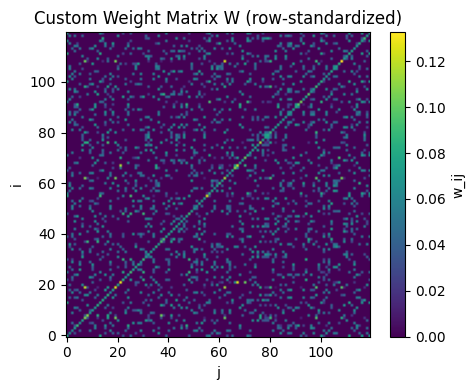

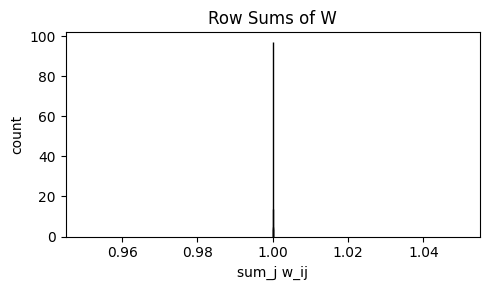

In [4]:
def validate_W(W, N):
    assert W.shape == (N, N), f"W must be {N}x{N}"
    if not np.all(np.isfinite(W)):
        raise ValueError("W has non-finite values")
    # ensure non-negative
    if np.any(W < 0):
        print("Warning: W has negative entries; check your construction.")

def row_standardize(W, eps=1e-12):
    s = W.sum(axis=1, keepdims=True)
    s = np.where(s < eps, 1.0, s)  # avoid divide-by-zero
    return W / s

def symmetrize_max(W):
    return np.maximum(W, W.T)

validate_W(W, N)
W = row_standardize(W)        # common choice
# W = symmetrize_max(W)       # optional, if desired

# Visualize W
plt.figure(figsize=(5,4))
plt.imshow(W, origin='lower', cmap='viridis')
plt.title("Custom Weight Matrix W (row-standardized)")
plt.xlabel("j"); plt.ylabel("i")
plt.colorbar(label="w_ij")
plt.tight_layout()
plt.show()

# Quick degree / row-sum check (should be ~1 after standardization)
plt.figure(figsize=(5,3))
plt.hist(W.sum(axis=1), bins=20, edgecolor='k')
plt.title("Row Sums of W")
plt.xlabel("sum_j w_ij"); plt.ylabel("count")
plt.tight_layout()
plt.show()

## 5) Local weighted OLS (instead of GWR)
For each focal location i, fit:
$$
\hat\beta_i = \arg\min_\beta \sum_{j=1}^{N} w_{ij} (y_j - X_j \beta)^2
\quad\Rightarrow\quad
\hat\beta_i = (X^\top W_i X + \lambda I)^{-1} X^\top W_i y,
$$
where $W_i=\mathrm{diag}(w_{i1},\dots,w_{iN})$ and small $\lambda$ stabilizes inverses.


In [5]:
def local_betas(X, y_vec, W, lam=1e-6):
    """
    Returns B (N x P): each row i is beta_hat for focal i using weights W[i,:].
    """
    N, P = X.shape
    B = np.zeros((N, P))
    XT = X.T
    I = np.eye(P)
    for i in range(N):
        w = W[i, :]
        # Weighted normal equations
        # XtWX = X^T diag(w) X  ;  XtWy = X^T diag(w) y
        XtWX = XT @ (w[:, None] * X)
        XtWy = XT @ (w * y_vec)
        try:
            B[i, :] = inv(XtWX + lam * I) @ XtWy
        except LinAlgError:
            # fallback: pseudo-inverse
            B[i, :] = np.linalg.pinv(XtWX + lam * I) @ XtWy
    return B

B_hat = local_betas(X, y_vec, W, lam=1e-4)  # N×P

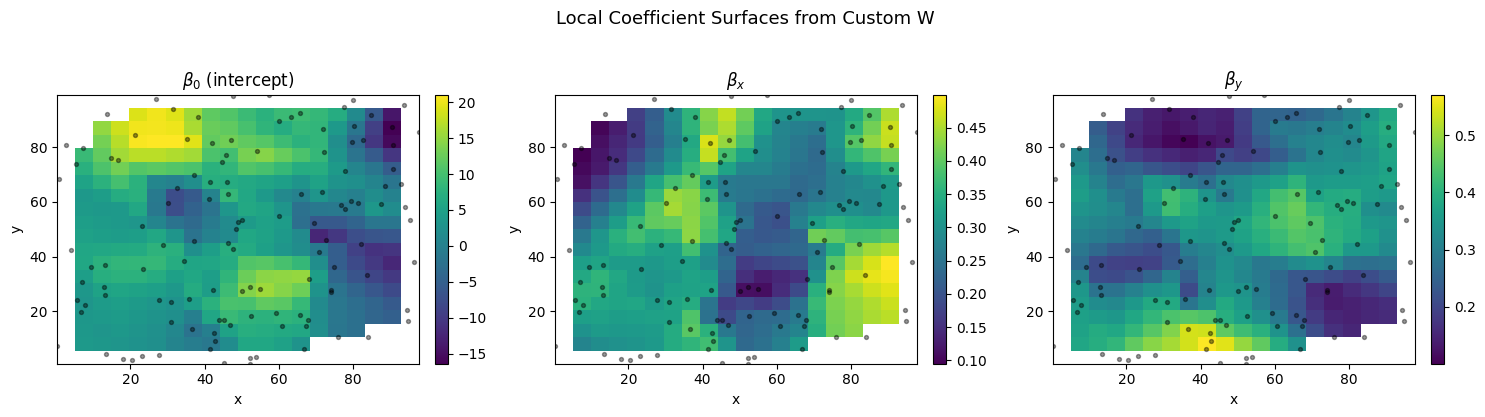

In [6]:
## Interpolate Coefficient Surfaces to a  20x20 Grid for visualization of the outcome
gx, gy = np.mgrid[x.min():x.max():20j, y.min():y.max():20j]

titles = [r"$\beta_0$ (intercept)", r"$\beta_x$", r"$\beta_y$"]
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for k, ax in enumerate(axes):
    surf = griddata(points=np.column_stack([x, y]),
                    values=B_hat[:, k],
                    xi=(gx, gy),
                    method='linear')
    im = ax.imshow(surf.T, origin='lower', extent=[x.min(), x.max(), y.min(), y.max()],
                   cmap='viridis', aspect='auto')
    ax.scatter(x, y, s=8, c='k', alpha=0.4)  # data locations
    ax.set_title(titles[k]); ax.set_xlabel("x"); ax.set_ylabel("y")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Local Coefficient Surfaces from Custom W", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()